In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("../images", exist_ok=True)

df_clean = pd.read_csv("../data/cleaned_cars.csv")
df_clean["log_price"] = np.log1p(df_clean["price"])
print(df_clean.shape)

(61024, 15)


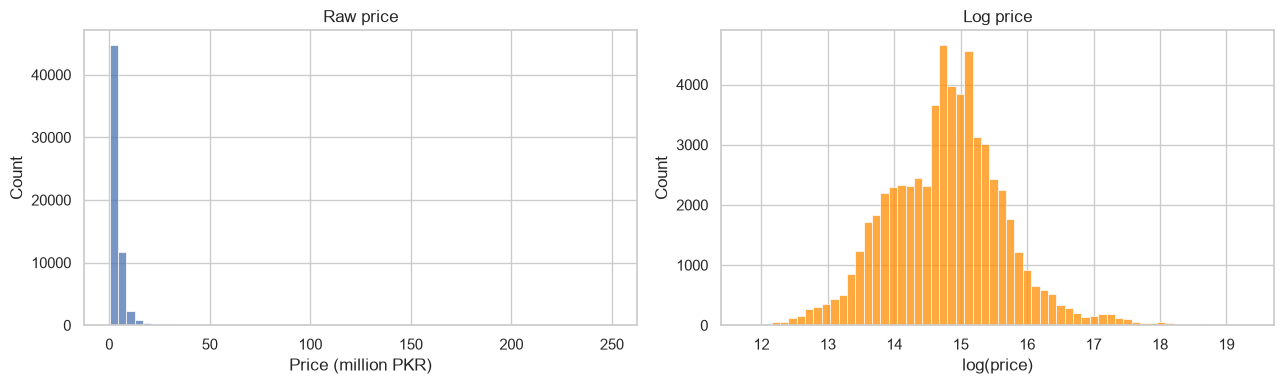

Skew raw: 9.65 | Skew log: 0.23


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_clean["price"] / 1e6, bins=60, ax=ax[0])
ax[0].set(title="Raw price", xlabel="Price (million PKR)")
sns.histplot(df_clean["log_price"], bins=60, ax=ax[1], color="darkorange")
ax[1].set(title="Log price", xlabel="log(price)")
plt.tight_layout()
plt.savefig("../images/01_price_distribution.png", dpi=150)
plt.show()

print("Skew raw:", round(df_clean["price"].skew(), 2),
      "| Skew log:", round(df_clean["log_price"].skew(), 2))

### Insight 1: Price is heavily right-skewed, so we model log(price)

Raw price has a skew of **9.65**: most cars are cheap, and a few supercars (up to 25 crore PKR) stretch the tail. After a log transform the skew drops to **0.23**, giving a near-symmetric bell shape.

**Takeaway:** We train on log(price) and convert predictions back to rupees with `expm1`. This makes the model learn percentage differences, so one very expensive car cannot dominate the errors.

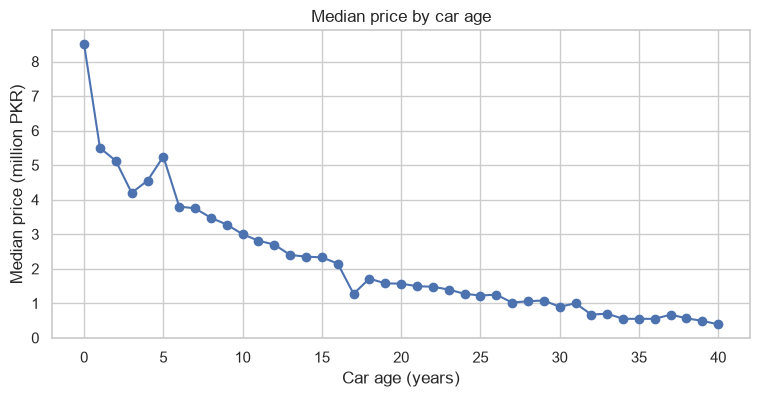

In [3]:
age = df_clean[df_clean["car_age"] <= 40].groupby("car_age")["price"].median() / 1e6
plt.figure(figsize=(9, 4))
age.plot(marker="o")
plt.title("Median price by car age")
plt.xlabel("Car age (years)")
plt.ylabel("Median price (million PKR)")
plt.savefig("../images/02_price_by_age.png", dpi=150)
plt.show()

### Insight 2: Cars lose value fastest in the first few years

Median price falls from about 8.5M PKR for a new car to about 4M by age 3, then declines slowly to under 1M by age 30+. The small bump at age 5 and the dip at age 17 are probably mix effects: some age groups contain more premium (or more budget) models, which moves their median.

**Takeaway:** `car_age` is a strong predictor, but it must be combined with make and model so the model is not misled by the mix of cars in each age group.

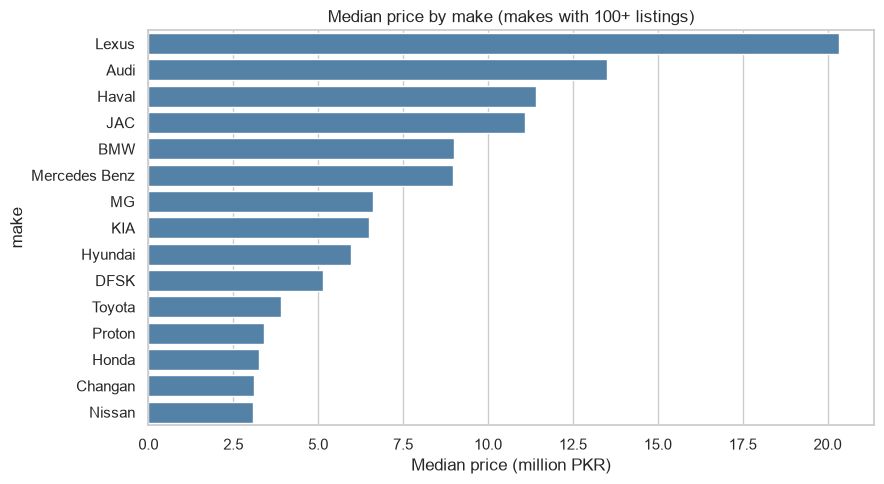

In [4]:
counts = df_clean["make"].value_counts()
big = counts[counts >= 100].index
top = (df_clean[df_clean["make"].isin(big)]
       .groupby("make")["price"].median()
       .sort_values(ascending=False).head(15) / 1e6)

plt.figure(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, color="steelblue")
plt.title("Median price by make (makes with 100+ listings)")
plt.xlabel("Median price (million PKR)")
plt.tight_layout()
plt.savefig("../images/03_price_by_make.png", dpi=150)
plt.show()

### Insight 3: Brand is a strong price signal

Among makes with 100+ listings, median price ranges from about 3M PKR (Nissan, Changan, Honda, Toyota) to about 20M PKR (Lexus). Audi, Haval and JAC follow at 11-13M, and BMW and Mercedes Benz sit near 9M.

Two results need care. JAC's median is high because, in this data, it sells mostly commercial vehicles, not luxury cars. Haval's median is high because its listings are mostly new, high-priced SUVs. So make alone does not tell the whole story, and model and body type matter too.

**Takeaway:** Median price differs by roughly 6x between the cheapest and most expensive makes, so `make` is a strong predictor. Brand tiers will be built from these medians (price levels, not quality rankings).

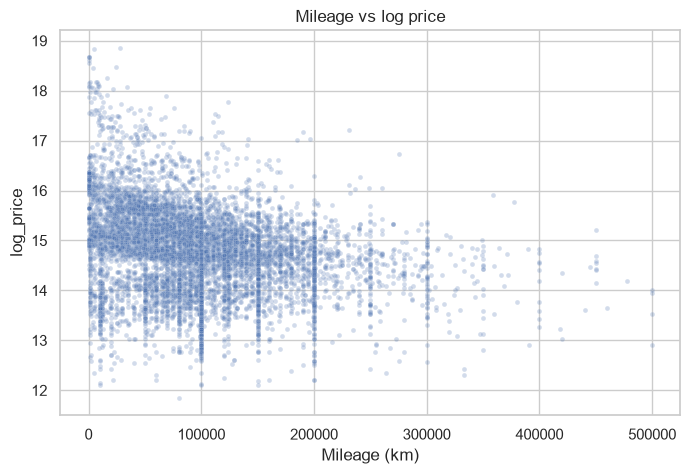

log_price     1.00
car_age      -0.64
mileage_km   -0.28
engine_cc     0.51
n_features    0.71
Name: log_price, dtype: float64


In [5]:
sample = df_clean.dropna(subset=["mileage_km"]).sample(8000, random_state=1)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="mileage_km", y="log_price", alpha=0.25, s=12)
plt.title("Mileage vs log price")
plt.xlabel("Mileage (km)")
plt.savefig("../images/04_mileage_vs_price.png", dpi=150)
plt.show()

print(df_clean[["log_price", "car_age", "mileage_km", "engine_cc", "n_features"]]
      .corr()["log_price"].round(2))

### Insight 4: Mileage matters less than age

Log price falls gently as mileage rises (correlation -0.28), much weaker than car age (-0.64). Older cars carry a wide range of mileage values, so mileage alone separates prices poorly. Vertical stripes at 100,000, 150,000 and 200,000 km show that sellers round their readings, so mileage is approximate.

`n_features` (+0.71) and `engine_cc` (+0.51) are the strongest numeric links with price. `n_features` partly reflects real extras and partly acts as a proxy for newer, higher-trim cars.

**Takeaway:** Car age is a stronger driver than mileage, so we will also test `mileage_per_year`, which normalises mileage by age.

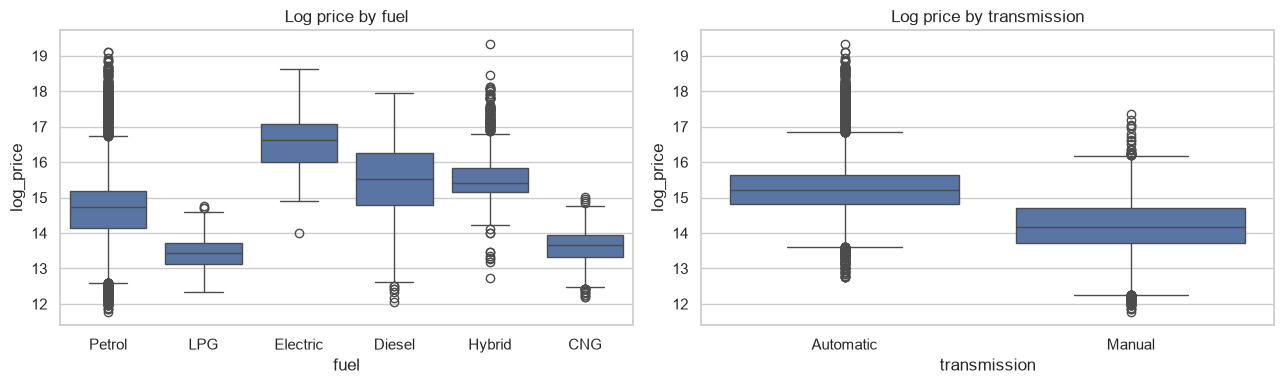

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_clean, x="fuel", y="log_price", ax=ax[0])
ax[0].set_title("Log price by fuel")
sns.boxplot(data=df_clean, x="transmission", y="log_price", ax=ax[1])
ax[1].set_title("Log price by transmission")
plt.tight_layout()
plt.savefig("../images/05_fuel_transmission.png", dpi=150)
plt.show()

### Insight 5: Fuel type and transmission clearly separate prices

Median log price is highest for Electric (about 16.6), followed by Diesel (about 15.5) and Hybrid (about 15.4). Petrol sits near 14.7, and CNG and LPG are lowest (about 13.5). Automatic cars have a median around 15.2 versus about 14.2 for Manual. Because the axis is log price, a gap of 1.0 means a price multiplier of roughly 2.7x.

The Electric group is small (about 470 listings) and made of new, expensive cars, so it reflects which cars are electric, not electricity itself.

**Takeaway:** Fuel and transmission are both useful categorical features. Electric, Diesel and Hybrid cost the most, CNG and LPG the least, and Automatics sell for roughly 2.7x the price of Manuals.

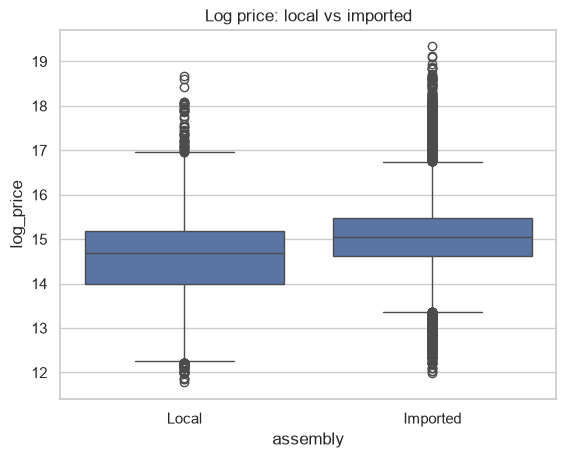

In [7]:
sns.boxplot(data=df_clean, x="assembly", y="log_price")
plt.title("Log price: local vs imported")
plt.savefig("../images/06_assembly.png", dpi=150)
plt.show()

### Insight 6: Imported cars carry a modest premium

Imported cars have a higher median log price (about 15.05) than locally assembled cars (about 14.7), but the boxes overlap heavily. Imported cars also show a long tail of low prices, since many are older Japanese kei cars and hatchbacks.

**Takeaway:** `assembly` is a weak predictor on its own. Its effect only becomes clear once age, make and model are taken into account.

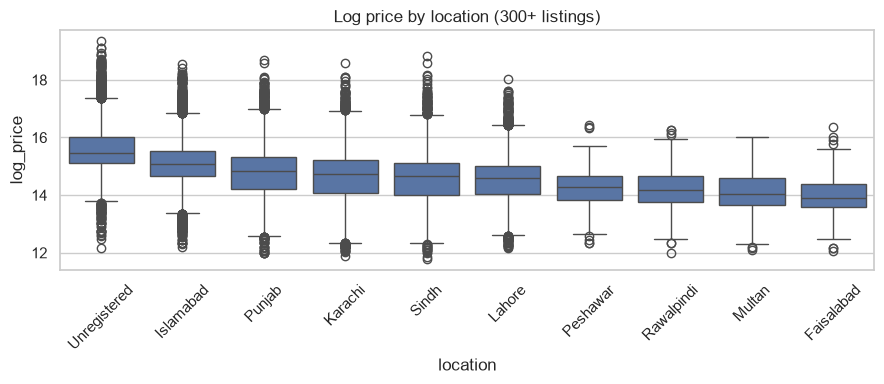

In [8]:
loc = df_clean["location"].value_counts()
big_loc = loc[loc >= 300].index
sub = df_clean[df_clean["location"].isin(big_loc)]
order = sub.groupby("location")["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(9, 4))
sns.boxplot(data=sub, x="location", y="log_price", order=order)
plt.xticks(rotation=45)
plt.title("Log price by location (300+ listings)")
plt.tight_layout()
plt.savefig("../images/07_location.png", dpi=150)
plt.show()

### Insight 7: Location shifts prices, and "Unregistered" cars are the most expensive

Among locations with 300+ listings, "Unregistered" has the highest median log price (about 15.4), followed by Islamabad (about 15.1). Punjab, Karachi, Sindh and Lahore sit in the middle, while Peshawar, Rawalpindi, Multan and Faisalabad are lowest (about 14).

"Unregistered" cars are not cheaper, which goes against a common assumption. This is probably a mix effect: unregistered listings are likely dominated by new or recently imported cars, which are expensive. So `is_registered` is useful as a proxy for newness and import status, not as a penalty for lacking registration.

**Takeaway:** Location is a useful categorical feature (Islamabad listings are priced above most other cities), and `is_registered` should be interpreted with care.

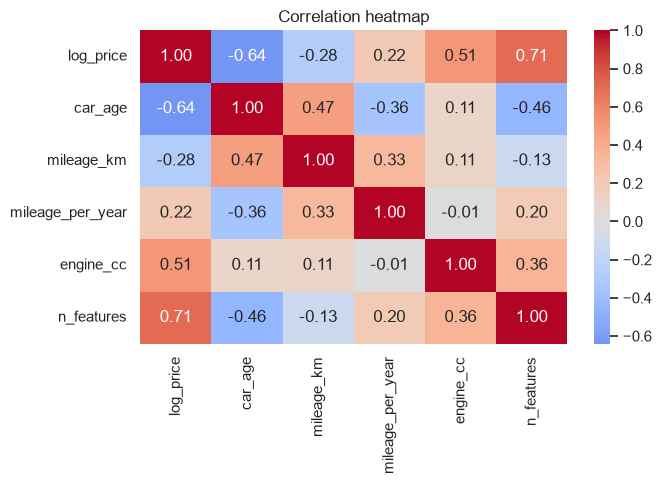

In [9]:
df_clean["mileage_per_year"] = df_clean["mileage_km"] / df_clean["car_age"].clip(lower=1)
num = ["log_price", "car_age", "mileage_km", "mileage_per_year", "engine_cc", "n_features"]

plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../images/08_heatmap.png", dpi=150)
plt.show()

### Insight 8: n_features and car_age are the strongest numeric drivers

Correlation with log price: `n_features` +0.71, `car_age` -0.64, `engine_cc` +0.51, `mileage_km` -0.28, `mileage_per_year` +0.22.

`mileage_per_year` is positive, not negative. New cars have a small age, so dividing by it inflates their yearly mileage, while they also cost more. It also correlates with `car_age` (-0.36), so it mostly encodes age. `n_features` and `car_age` correlate at -0.46 (newer cars list more features), so these inputs overlap.

**Takeaway:** `n_features` and `car_age` are the main numeric drivers. We keep `mileage_per_year` as a candidate and let feature importance show whether it earns its place.

In [10]:
q1, q3 = df_clean["log_price"].quantile([.25, .75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = (df_clean["log_price"] < low) | (df_clean["log_price"] > high)

print(f"IQR bounds in PKR: {np.expm1(low):,.0f} to {np.expm1(high):,.0f}")
print("Rows outside the bounds:", out.sum(), f"({out.mean():.1%})")

IQR bounds in PKR: 279,095 to 23,438,176
Rows outside the bounds: 1268 (2.1%)


### Outlier check (IQR on log price)

IQR bounds on log price correspond to roughly 279,095 to 23,438,176 PKR. Only 1,268 rows (2.1%) fall outside them. These are real listings (1980s budget cars and luxury imports such as G-Class and Urus), not data errors, so they are kept. Obvious errors were already handled in cleaning (mileage and engine typos set to missing, years before 1970 dropped).

**Takeaway:** We train on log(price), which keeps extreme prices from dominating the model, instead of deleting outliers.